# Effect of Dropout on Overfitting in Neural Networks

## Introduction
Neural networks are powerful models used for classification and prediction tasks. However, they often suffer from overfitting, where the model performs well on training data but poorly on unseen data. This tutorial explores how dropout helps reduce overfitting and improves model generalization.

In [1]:
pip install tensorflow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


## Dataset Description
The MNIST dataset is used in this experiment. It consists of handwritten digit images (0–9). Each image is 28x28 pixels and is commonly used for testing machine learning models.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [15]:
# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [16]:
# Normalize data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# One-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

## Model Without Dropout
This model does not use dropout. It is expected to overfit the training data due to its capacity to memorize patterns.

In [17]:
model1 = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [18]:
model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history1 = model1.fit(
    x_train, y_train,
    epochs=15,
    validation_data=(x_test, y_test)
)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8784 - loss: 0.4138 - val_accuracy: 0.9614 - val_loss: 0.1216
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9681 - loss: 0.1052 - val_accuracy: 0.9694 - val_loss: 0.0994
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9806 - loss: 0.0646 - val_accuracy: 0.9749 - val_loss: 0.0826
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9844 - loss: 0.0484 - val_accuracy: 0.9739 - val_loss: 0.0866
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9878 - loss: 0.0392 - val_accuracy: 0.9762 - val_loss: 0.0844
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9894 - loss: 0.0304 - val_accuracy: 0.9745 - val_loss: 0.0923
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9922 - loss: 0.0244 - val_accuracy: 0.9756 - val_loss: 0.0933
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9920 - loss: 0.0231 - 

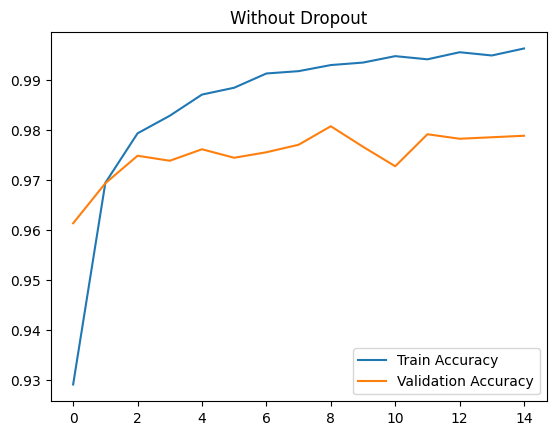

In [20]:
plt.plot(history1.history['accuracy'], label='Train Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Without Dropout")
plt.show()

### Observation (Without Dropout)
The training accuracy increases significantly, while the validation accuracy is lower. This gap indicates overfitting, where the model memorizes training data but does not generalize well.

## Model With Dropout
Dropout is applied to randomly disable neurons during training. This helps reduce overfitting and improves generalization.

In [21]:
model2 = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [22]:
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history2 = model2.fit(
    x_train, y_train,
    epochs=15,
    validation_data=(x_test, y_test)
)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7036 - loss: 0.9090 - val_accuracy: 0.9433 - val_loss: 0.1872
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9090 - loss: 0.3268 - val_accuracy: 0.9539 - val_loss: 0.1547
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9235 - loss: 0.2777 - val_accuracy: 0.9624 - val_loss: 0.1282
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9339 - loss: 0.2371 - val_accuracy: 0.9645 - val_loss: 0.1187
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9387 - loss: 0.2220 - val_accuracy: 0.9635 - val_loss: 0.1256
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9396 - loss: 0.2114 - val_accuracy: 0.9667 - val_loss: 0.1138
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9446 - loss: 0.2000 - val_accuracy: 0.9673 - val_loss: 0.1085
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9482 - loss: 0.1836 - 

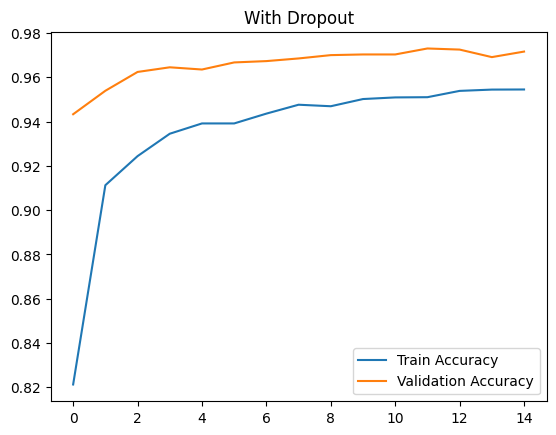

In [26]:
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("With Dropout")
plt.show()

### Observation (With Dropout)
The gap between training and validation accuracy is reduced. This indicates that the model generalizes better and overfitting is minimized. The validation accuracy may even be slightly higher due to dropout being active only during training.

## Comparison

| Model | Training Accuracy | Validation Accuracy | Observation |
|------|------------------|--------------------|-------------|
| Without Dropout | High | Lower | Overfitting |
| With Dropout | Moderate | High | Better generalization |

## Effect of Different Dropout Values

- Dropout (0.2): Slight overfitting may still occur
- Dropout (0.5): Best balance between training and validation performance
- Dropout (0.8): Model may underfit due to excessive information loss

## Conclusion
Dropout is an effective regularization technique that reduces overfitting in neural networks. By randomly disabling neurons during training, it forces the model to learn more generalized features. However, choosing an appropriate dropout rate is important, as too much dropout can lead to underfitting.